Conectando ao DuckDB...


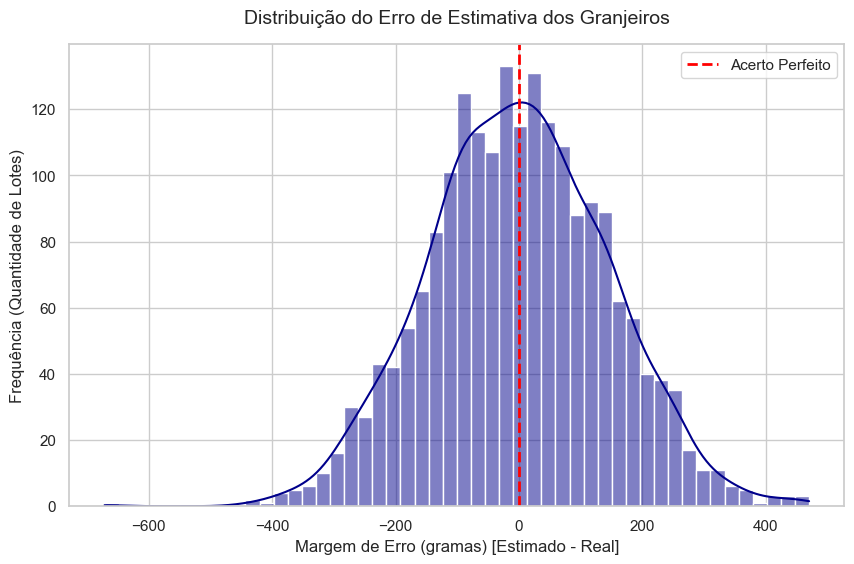

In [8]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional plot style
sns.set_theme(style="whitegrid")

# Connect to DuckDB warehouse
print("Conectando ao DuckDB...")
conn = duckdb.connect("../data/processed/warehouse.duckdb")

# Query: fetch farmer error margins
query = """
    SELECT 
        farmer_id,
        farmer_error_margin_g
    FROM fct_slaughter_batches
"""

# Load query result into Pandas DataFrame
df_error = conn.execute(query).df()

# Plot histogram of estimation errors
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df_error,
    x="farmer_error_margin_g",
    bins=50,
    kde=True,
    color="darkblue"
)

# Titles and labels in Portuguese
plt.title("Distribuição do Erro de Estimativa dos Granjeiros", fontsize=14, pad=15)
plt.xlabel("Margem de Erro (gramas) [Estimado - Real]", fontsize=12)
plt.ylabel("Frequência (Quantidade de Lotes)", fontsize=12)

# Add reference line at zero (perfect estimate)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Acerto Perfeito')
plt.legend()
plt.show()

# Close connection
conn.close()



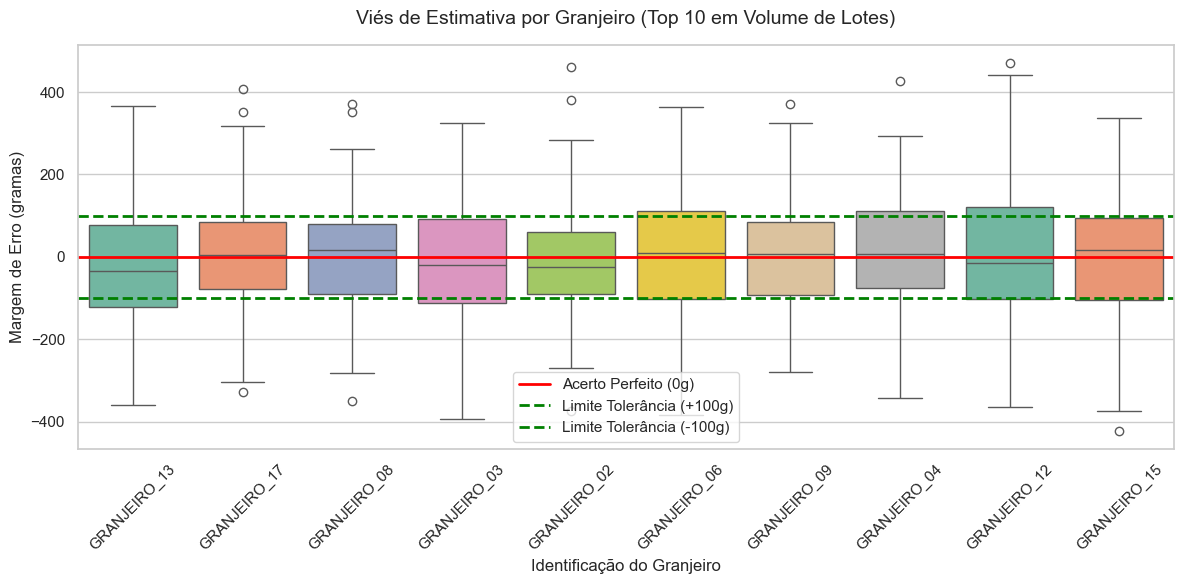

In [ ]:
# Independent cell for farmer bias boxplot
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Connect and fetch data
conn = duckdb.connect("../data/processed/warehouse.duckdb")
query = """SELECT farmer_id, farmer_error_margin_g FROM fct_slaughter_batches"""
df_error = conn.execute(query).df()
conn.close()  # Always close connection

# Plot boxplot of estimation bias
plt.figure(figsize=(12, 6))

# Select top 10 farmers by batch volume
top_farmers = df_error['farmer_id'].value_counts().nlargest(10).index
df_top_farmers = df_error[df_error['farmer_id'].isin(top_farmers)]

# Create boxplot
sns.boxplot(
    data=df_top_farmers,
    x='farmer_id',
    y='farmer_error_margin_g',
    hue='farmer_id',
    palette='Set2',
    legend=False
)

# Reference lines: perfect estimate and tolerance limits
plt.axhline(y=0, color='red', linestyle='-', linewidth=2, label='Acerto Perfeito (0g)')
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='Limite Tolerância (+100g)')
plt.axhline(y=-100, color='green', linestyle='--', linewidth=2, label='Limite Tolerância (-100g)')

# Titles and labels 
plt.title("Viés de Estimativa por Granjeiro (Top 10 em Volume de Lotes)", fontsize=14, pad=15)
plt.xlabel("Identificação do Granjeiro", fontsize=12)
plt.ylabel("Margem de Erro (gramas)", fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()


Buscando dados biológicos e de manejo...


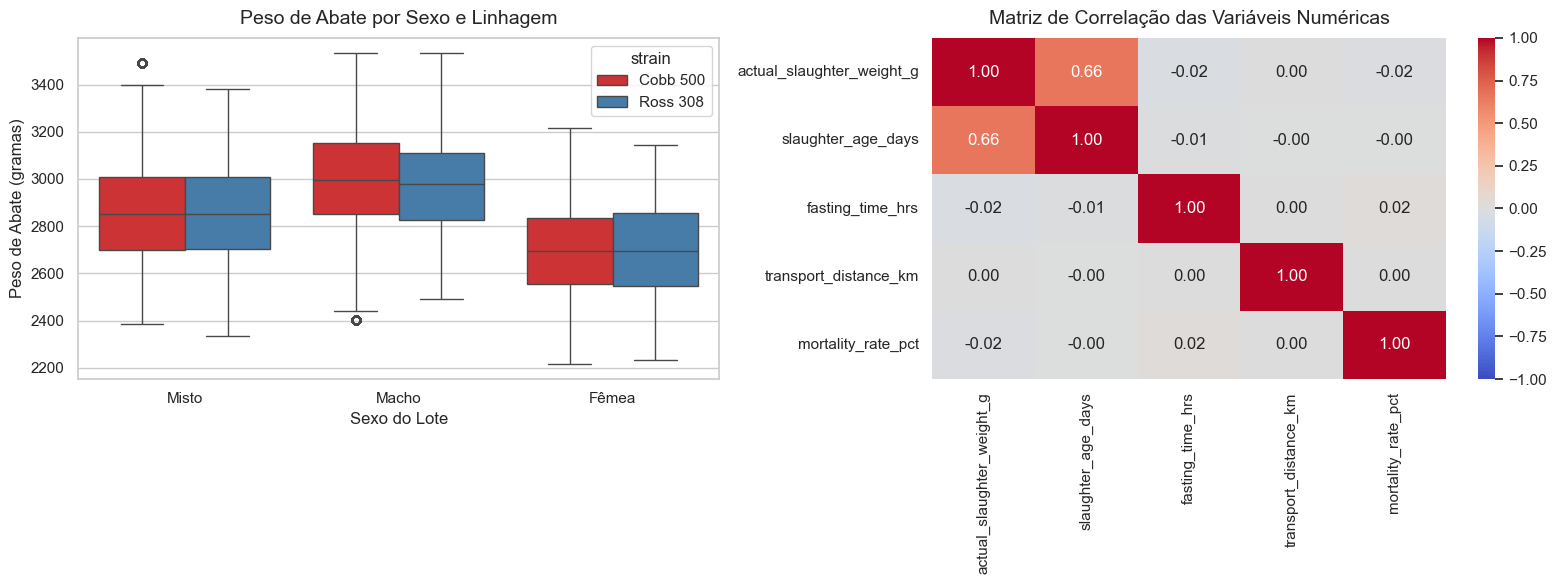

In [15]:
# Independent cell for biological and management analysis
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Connect and fetch data with JOIN
print("Buscando dados biológicos e de manejo...")
conn = duckdb.connect("../data/processed/warehouse.duckdb")

# Star Schema join: fact table with farm dimension
query = """
    SELECT 
        f.strain,
        f.flock_sex,
        f.fasting_time_hrs,
        d.transport_distance_km,  -- Column from dim_farm
        f.mortality_rate_pct,
        f.actual_slaughter_weight_g,
        date_diff('day', f.placement_date, f.slaughter_date) AS slaughter_age_days
    FROM fct_slaughter_batches f
    JOIN dim_farm d ON f.farm_id = d.farm_id
"""
df_bio = conn.execute(query).df()
conn.close()  # Always close connection

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: impact of sex and strain on final weight (boxplot)
sns.boxplot(
    data=df_bio, 
    x='flock_sex', 
    y='actual_slaughter_weight_g', 
    hue='strain', 
    palette='Set1', 
    ax=axes[0]
)
axes[0].set_title("Peso de Abate por Sexo e Linhagem", fontsize=14, pad=10)
axes[0].set_xlabel("Sexo do Lote", fontsize=12)
axes[0].set_ylabel("Peso de Abate (gramas)", fontsize=12)

# Subplot 2: correlation matrix (heatmap)
num_cols = [
    'actual_slaughter_weight_g', 
    'slaughter_age_days', 
    'fasting_time_hrs', 
    'transport_distance_km', 
    'mortality_rate_pct'
]
corr_matrix = df_bio[num_cols].corr()

sns.heatmap(
    corr_matrix, 
    annot=True,       # Show correlation values
    cmap='coolwarm',  # Blue negative, red positive
    fmt=".2f", 
    ax=axes[1], 
    vmin=-1, 
    vmax=1
)
axes[1].set_title("Matriz de Correlação das Variáveis Numéricas", fontsize=14, pad=10)

plt.tight_layout()
plt.show()
